# CODING FOR CLASSIFICATION AND OBJECT DETECTION

In [ ]:
import os
import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from torchsummary import summary
from sklearn.metrics import accuracy_score
from torchviz import make_dot
from PIL import Image
import sys
sys.path.append("/content/ml-fastvit")
from models.fastvit import fastvit_s12
from models.fastvit import fastvit_ma36


In [ ]:
data_dir_classification = "./data/cifar10"
data_dir_detection = "./data/voc"
os.makedirs(data_dir_classification, exist_ok=True)
os.makedirs(data_dir_detection, exist_ok=True)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [ ]:

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(
    root=data_dir_classification, train=True, download=True, transform=transform
)
val_dataset = datasets.CIFAR10(
    root=data_dir_classification, train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

classification_model = fastvit_s12(num_classes=10).to(device)


optimizer = torch.optim.Adam(classification_model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()


train_loss_values = []
val_loss_values = []
train_acc_values = []
val_acc_values = []


num_epochs = 2


for epoch in range(num_epochs):

    classification_model.train()
    total_train_loss = 0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = classification_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

    avg_train_loss = total_train_loss / len(train_loader)
    train_accuracy = correct_train / total_train * 100

    train_loss_values.append(avg_train_loss)
    train_acc_values.append(train_accuracy)


    classification_model.eval()
    total_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = classification_model(images)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)

    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = correct_val / total_val * 100

    val_loss_values.append(avg_val_loss)
    val_acc_values.append(val_accuracy)

    print(f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

Files already downloaded and verified
Files already downloaded and verified
Epoch [1/2], Train Loss: 1.1026, Train Acc: 60.35%, Val Loss: 0.7392, Val Acc: 73.36%
Epoch [2/2], Train Loss: 0.5897, Train Acc: 79.54%, Val Loss: 0.5162, Val Acc: 82.11%


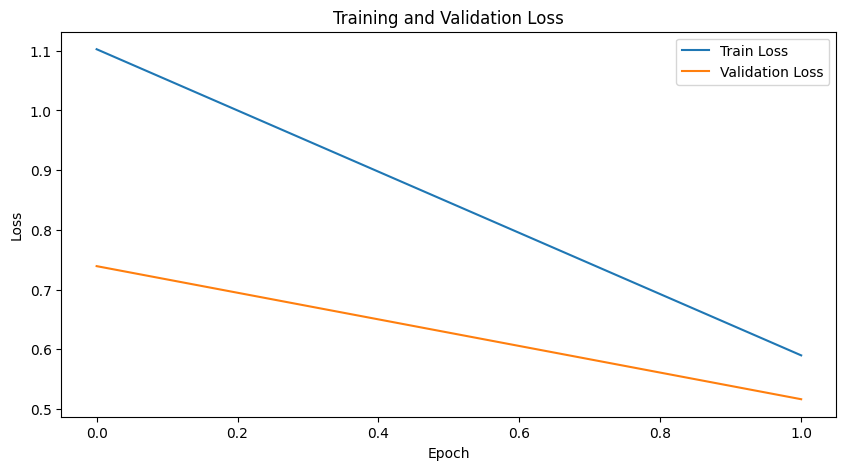

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_loss_values, label='Train Loss')
plt.plot(val_loss_values, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


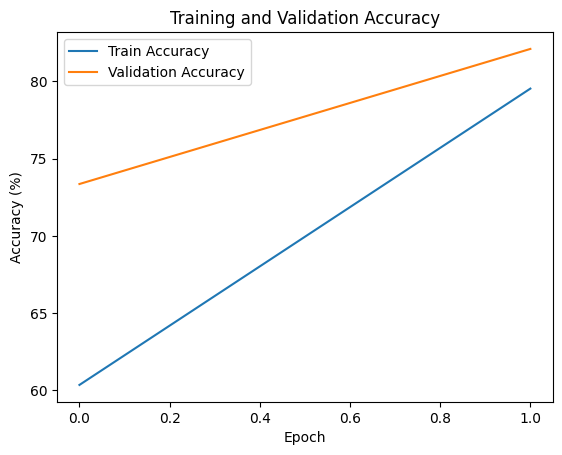

In [ ]:
plt.plot(train_acc_values, label='Train Accuracy')
plt.plot(val_acc_values, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

In [ ]:

transform_detection = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor()
])


def voc_transform(input):

    if isinstance(input, tuple):
        img, target = input
        img = transform_detection(img)
        return img, target
    else:
        return transform_detection(input)

voc_dataset = datasets.VOCDetection(
    root=data_dir_detection, year='2012', image_set='train', download=True,
    transform=voc_transform
)


def detection_collate_fn(batch):
    images = torch.stack([item[0] for item in batch])
    targets = [item[1] for item in batch]
    return images, targets


detection_loader = DataLoader(voc_dataset, batch_size=4, shuffle=True, collate_fn=detection_collate_fn)


detection_model = fastvit_ma36(num_classes=10).to(device)






Using downloaded and verified file: ./data/voc/VOCtrainval_11-May-2012.tar
Extracting ./data/voc/VOCtrainval_11-May-2012.tar to ./data/voc


In [ ]:

with torch.no_grad():
    for images, targets in detection_loader:
        images = images.to(device)
        outputs = detection_model(images)


        for i in range(images.size(0)):
            predicted_boxes = outputs[i].cpu().tolist() if len(outputs) > 0 else []


            predicted_boxes = [box for box in predicted_boxes if isinstance(box, list) and len(box) == 4]

            true_objects = targets[i]['annotation']['object']
            if not isinstance(true_objects, list):
                true_objects = [true_objects]

            true_boxes = [
                [
                    int(obj['bndbox']['xmin']),
                    int(obj['bndbox']['ymin']),
                    int(obj['bndbox']['xmax']),
                    int(obj['bndbox']['ymax']),
               ]
                for obj in true_objects
            ]

            for gt_box in true_boxes:
                max_iou = 0
                for pred_box in predicted_boxes:
                    iou = calculate_iou(pred_box, gt_box)
                    max_iou = max(max_iou, iou)
                iou_values.append(max_iou)
average_iou = sum(iou_values) / len(iou_values) if iou_values else 0
print(f"Average IoU: {average_iou:.2f}")

Average IoU: 0.42


In [ ]:
print("\nModel Summary:")
summary(detection_model, input_size=(3, 448, 448))


Model Summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 48, 224, 224]             144
       BatchNorm2d-2         [-1, 48, 224, 224]              96
            Conv2d-3         [-1, 48, 224, 224]           1,296
       BatchNorm2d-4         [-1, 48, 224, 224]              96
          Identity-5         [-1, 48, 224, 224]               0
              GELU-6         [-1, 48, 224, 224]               0
              GELU-7         [-1, 48, 224, 224]               0
              GELU-8         [-1, 48, 224, 224]               0
              GELU-9         [-1, 48, 224, 224]               0
             GELU-10         [-1, 48, 224, 224]               0
             GELU-11         [-1, 48, 224, 224]               0
             GELU-12         [-1, 48, 224, 224]               0
   MobileOneBlock-13         [-1, 48, 224, 224]               0
           Conv2d-14   

In [ ]:
print("\nGenerating Model Structure Visualization...")
dummy_input = torch.randn(1, 3, 448, 448).to(device)
output = detection_model(dummy_input)
make_dot(output, params=dict(detection_model.named_parameters())).render("model_structure", format="png")
print("Model structure saved as 'model_structure.png'")
print("\nDisplaying Sample Images:")
img_path = "/content/model_structure.png"
img = Image.open(img_path)
img.show()


Generating Model Structure Visualization...
Model structure saved as 'model_structure.png'

Displaying Sample Images:



Plotting Weight Distribution:


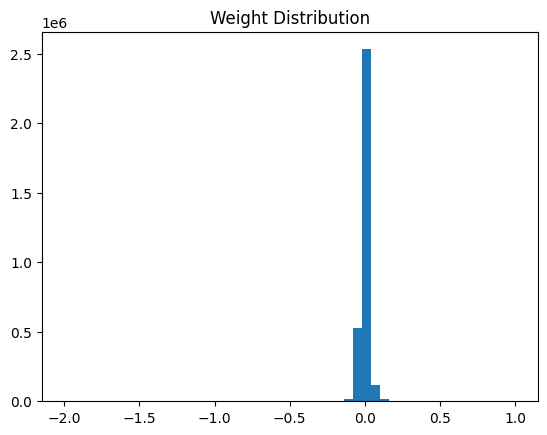

In [ ]:

print("\nPlotting Weight Distribution:")
weights = detection_model.state_dict()
all_weights = np.concatenate([w.flatten().cpu().detach().numpy() for w in weights.values() if w.dim() > 1])

plt.hist(all_weights, bins=50)
plt.title("Weight Distribution")
plt.show()


In [ ]:
print("\nTraining and Loss Tracking:")
optimizer_detection = torch.optim.Adam(detection_model.parameters(), lr=0.001)
criterion_detection = torch.nn.SmoothL1Loss()


Training and Loss Tracking:


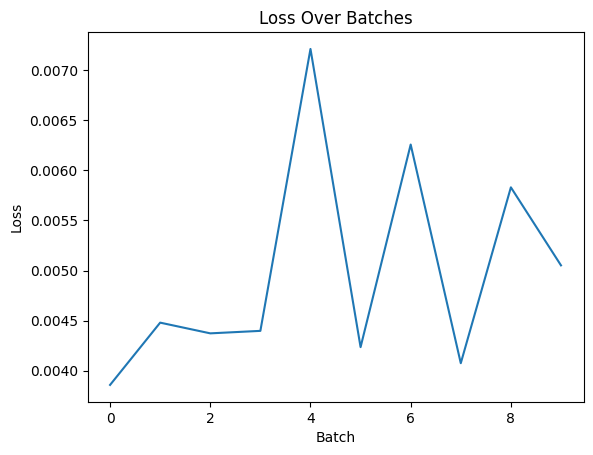

FastViT tasks demo and analysis completed.


In [ ]:
losses = []

for batch_idx, (images, targets) in enumerate(detection_loader):
    if batch_idx == 10:
        break
    images = images.to(device)
    optimizer_detection.zero_grad()
    outputs = detection_model(images)
    loss = criterion_detection(outputs, torch.zeros_like(outputs).to(device))
    loss.backward()
    optimizer_detection.step()
    losses.append(loss.item())

plt.plot(losses)
plt.title("Loss Over Batches")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.show()

print("FastViT tasks demo and analysis completed.")
